# PREDICTING FREIGHT COST INVOICE INTELLIGENCE

*objective* :- predicting freight cost for  a vendor invoice using qauntity and dollars, to improve forecating , bugdeting and vendor negotiation

In [1]:
import pandas as pd
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt

In [2]:

# Correct full path
conn = sqlite3.connect(r'C:\Users\Ansh Mishra\Desktop\PythoncourseML\datasets\inventory.db')

# Check tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('purchases',), ('purchase_prices',), ('vendor_invoice',), ('begin_inventory',), ('end_inventory',)]


In [3]:
tables = ['purchases', 'purchase_prices', 'vendor_invoice', 'begin_inventory', 'end_inventory']

for table in tables:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    df.to_csv(f'{table}.csv', index=False)
    print(f'{table}.csv saved!')

conn.close()

purchases.csv saved!
purchase_prices.csv saved!
vendor_invoice.csv saved!
begin_inventory.csv saved!
end_inventory.csv saved!


In [4]:
df_purchases = pd.read_csv('purchases.csv')
df_purchases.head()         


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


In [5]:
df_purchases = pd.read_csv('purchase_prices.csv')
df_purchases.head()    

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


In [6]:
df_vendor_invoice = pd.read_csv('vendor_invoice.csv')
df_vendor_invoice .head()   


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [7]:
df_vendor_invoice[['Quantity' ,'Dollars' , 'Freight' ]].corr()
# to get corelation 

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


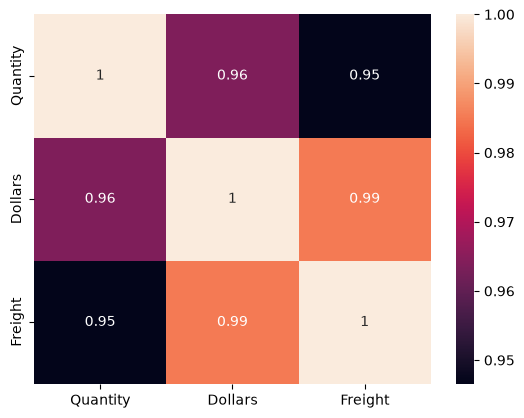

C:\Users\Ansh Mishra\AppData\Local\Temp\ipykernel_26880\1082928847.py:10: UserWarning: Mismatched number of handles and labels: len(handles) = 7 len(labels) = 8
  plt.legend('Dollars' , 'Quantity')
C:\Users\Ansh Mishra\AppData\Local\Temp\ipykernel_26880\1082928847.py:10: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Dollars' , 'Quantity')


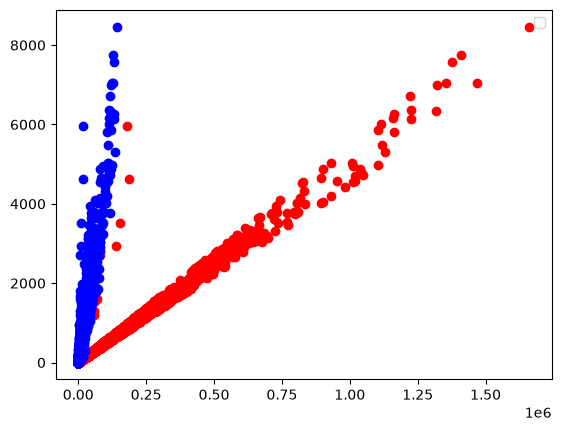

In [8]:
#relationship between quantity , dolloars and freight
#lets plot some graph for that

sns.heatmap(df_vendor_invoice[['Quantity' ,'Dollars' , 'Freight' ]].corr() ,annot=True)
plt.show()

plt.scatter( df_vendor_invoice['Dollars'] , df_vendor_invoice['Freight'] , color = 'r')

plt.scatter( df_vendor_invoice['Quantity'] , df_vendor_invoice['Freight'] , color = 'b')
plt.legend('Dollars' , 'Quantity')
plt.show()



In [9]:
stats = df_vendor_invoice.describe()
stats

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


In [10]:
df_vendor_invoice['freight_per_unit'] = (
    df_vendor_invoice['Freight'] / df_vendor_invoice['Quantity']
)


# extract 25% and 75% directly!
low_quantity  = stats.loc['25%', 'Quantity']   
high_quantity = stats.loc['75%', 'Quantity']
   

In [11]:
# rows where quantity is LOW
df_vendor_invoice.loc[
    df_vendor_invoice['Quantity'] < low_quantity, 
    'freight_per_unit'
].mean()
  


np.float64(0.09489854253138316)

In [12]:
df_vendor_invoice.loc[
    df_vendor_invoice['Quantity'] > high_quantity, 
    'freight_per_unit'
].mean()

np.float64(0.049077654690759046)

In [13]:
df_vendor_invoice .isnull().sum()
df_vendor_invoice .drop('Approval' , axis =1)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,0.221809
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,0.033117


les start to train the model
so, my approach would be like to run on evry model & then i will see what peform the best

In [41]:
from sklearn.model_selection import train_test_split
X = df_vendor_invoice[[ 'Dollars']]
Y = df_vendor_invoice[['Freight']]

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [49]:
X_train,X_test, Y_train , Y_test = train_test_split(X_norm , Y , test_size=0.2 , random_state=42)


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import sklearn as sk
import math

In [51]:
print(sk.__version__)

1.8.0


In [52]:
model1 = LinearRegression()
model1.fit(X_train , Y_train )

model2 = DecisionTreeRegressor()
model2.fit(X_train , Y_train )

model3 = RandomForestRegressor()
model3.fit(X_train , Y_train )




c:\Users\Ansh Mishra\Desktop\PythoncourseML\venv1\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [53]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [54]:
evaluate_model(model1, X_test , Y_test , 'LinearRegression')
evaluate_model(model2 , X_test , Y_test , 'DecisionTreeRegressor')
evaluate_model(model3 , X_test , Y_test , 'RandomForestRegressor')


LinearRegression Performance:
MAE  : 24.11
RMSE : 124.72
R²   : 96.99%

DecisionTreeRegressor Performance:
MAE  : 32.65
RMSE : 163.74
R²   : 94.81%

RandomForestRegressor Performance:
MAE  : 28.28
RMSE : 144.14
R²   : 95.98%


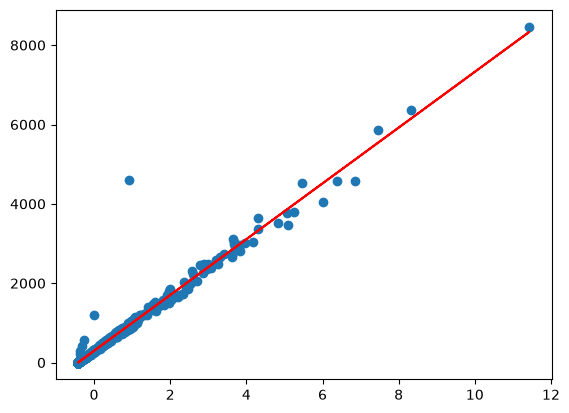

In [55]:
plt.scatter(X_test ,Y_test)
plt.plot(X_test, model1.predict(X_test) , color = 'red')

In [56]:
input_data = {
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

model1.predict(df)

c:\Users\Ansh Mishra\Desktop\PythoncourseML\venv1\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([[13010128.68896282],
       [ 6329403.92607067]])